In [1]:
%pdb on

Automatic pdb calling has been turned ON


In [2]:
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tiktoken
from thefuzz import fuzz

In [3]:
category_untuned = []
with open("category-gpt-4.1-mini-2025-04-14.jsonl") as file:
    for line in file:
        category_untuned.append(json.loads(line))

In [4]:
category_finetuned = []
with open("category-ft:gpt-4.1-mini-2025-04-14:u-chicago:cgfp-category-try2:CphJxpT2.jsonl") as file:
    for line in file:
        category_finetuned.append(json.loads(line))

In [5]:
tag_untuned = []
with open("tag-gpt-4.1-mini-2025-04-14.jsonl") as file:
    for line in file:
        tag_untuned.append(json.loads(line))

In [6]:
tag_finetuned = []
with open("tag-ft:gpt-4.1-mini-2025-04-14:u-chicago:cgfp-tag-try2:CphN8ams.jsonl") as file:
    for line in file:
        tag_finetuned.append(json.loads(line))

In [7]:
def category_to_df(data):
    df_input = []
    df_category = []
    df_subcategory = []
    df_multiplicity = []
    df_inputfuzz = []
    df_actual_category = []
    df_good_category = []
    df_good_subcategory = []

    for pair in data:
        actual, expected = pair["actual"]["food_products"], pair["expected"]["food_products"]
        len_actual = len([x for x in actual if isinstance(x, dict) and "input" in x])
        for index, row in enumerate(expected):
            df_input.append(row["input"])
            df_category.append(row["category"])
            df_subcategory.append(row.get("subcategory", ""))
            df_multiplicity.append(len(expected))
            df_inputfuzz.append(fuzz.ratio(row["input"], actual[index].get("input", "")) if index < len_actual else 0)
            df_actual_category.append(actual[index].get("category", "") if index < len_actual else "")
            df_good_category.append(row["category"] == actual[index].get("category", "") if index < len_actual else False)
            df_good_subcategory.append(row.get("subcategory", "") == actual[index].get("subcategory", "") if index < len_actual else False)
    
    return pd.DataFrame({
        "input": df_input,
        "category": df_category,
        "subcategory": df_subcategory,
        "multiplicity": df_multiplicity,
        "inputfuzz": df_inputfuzz,
        "actual_category": df_actual_category,
        "good_category": df_good_category,
        "good_subcategory": df_good_subcategory,
    })

df_category_untuned = category_to_df(category_untuned)
df_category_finetuned = category_to_df(category_finetuned)

In [8]:
def tag_to_df(data):
    df_input = []
    df_multiplicity = []
    df_basic_type = []
    df_sub_types = []
    df_flavored = []
    df_shape = []
    df_meat_cut = []
    df_meat_skin = []
    df_meat_bone = []
    df_seed_pitted = []
    df_processing = []
    df_cooked = []
    df_whole_grain = []
    df_sodium_level = []
    df_caffeine = []
    df_diet = []
    df_reduced_sugar = []
    df_sweetened = []
    df_additives = []
    df_accommodation = []
    df_frozen = []
    df_packaging = []
    df_commodity = []

    filled = Counter()
    
    for pair in data:
        actual, expected = pair["actual"]["food_products"], pair["expected"]["food_products"]
        for index, row in enumerate(expected):
            df_input.append(row["input"])
            df_multiplicity.append(len(expected))
            len_actual = len([x for x in actual if isinstance(x, dict) and "input" in x])
            df_basic_type.append(row.get("basic_type", "") == actual[index].get("basic_type", "") if index < len_actual else False)
            df_sub_types.append(row.get("sub_types", []) == actual[index].get("sub_types", []) if index < len_actual else False)
            df_flavored.append(row.get("flavored", "") == actual[index].get("flavored", "") if index < len_actual else False)
            df_shape.append(row.get("shape", "") == actual[index].get("shape", "") if index < len_actual else False)
            df_meat_cut.append(row.get("meat_cut", "") == actual[index].get("meat_cut", "") if index < len_actual else False)
            df_meat_skin.append(row.get("meat_skin", "") == actual[index].get("meat_skin", "") if index < len_actual else False)
            df_meat_bone.append(row.get("meat_bone", "") == actual[index].get("meat_bone", "") if index < len_actual else False)
            df_seed_pitted.append(row.get("seed_pitted", "") == actual[index].get("seed_pitted", "") if index < len_actual else False)
            df_processing.append(row.get("processing", "") == actual[index].get("processing", "") if index < len_actual else False)
            df_cooked.append(row.get("cooked", "") == actual[index].get("cooked", "") if index < len_actual else False)
            df_whole_grain.append(row.get("whole_grain", "") == actual[index].get("whole_grain", "") if index < len_actual else False)
            df_sodium_level.append(row.get("sodium_level", "") == actual[index].get("sodium_level", "") if index < len_actual else False)
            df_caffeine.append(row.get("caffeine", "") == actual[index].get("caffeine", "") if index < len_actual else False)
            df_diet.append(row.get("diet", "") == actual[index].get("diet", "") if index < len_actual else False)
            df_reduced_sugar.append(row.get("reduced_sugar", "") == actual[index].get("reduced_sugar", "") if index < len_actual else False)
            df_sweetened.append(row.get("sweetened", "") == actual[index].get("sweetened", "") if index < len_actual else False)
            df_additives.append(row.get("additives", "") == actual[index].get("additives", "") if index < len_actual else False)
            df_accommodation.append(row.get("accommodation", "") == actual[index].get("accommodation", "") if index < len_actual else False)
            df_frozen.append(row.get("frozen", "") == actual[index].get("frozen", "") if index < len_actual else False)
            df_packaging.append(row.get("packaging", "") == actual[index].get("packaging", "") if index < len_actual else False)
            df_commodity.append(row.get("commodity", "") == actual[index].get("commodity", "") if index < len_actual else False)
            for field in [
                "flavored", "shape", "meat_cut", "meat_skin", "meat_bone", "seed_pitted", "processing", "cooked", "whole_grain", "sodium_level",
                "caffeine", "diet", "reduced_sugar", "sweetened", "additives", "accommodation", "frozen", "packaging", "commodity",
            ]:
                filled[field] += int(row.get(field, "") != "")

    return pd.DataFrame({
        "input": df_input,
        "multiplicity": df_multiplicity,
        "basic_type": df_basic_type,
        "sub_types": df_sub_types,
        "flavored": df_flavored,
        "shape": df_shape,
        "meat_cut": df_meat_cut,
        "meat_skin": df_meat_skin,
        "meat_bone": df_meat_bone,
        "seed_pitted": df_seed_pitted,
        "processing": df_processing,
        "cooked": df_cooked,
        "whole_grain": df_whole_grain,
        "sodium_level": df_sodium_level,
        "caffeine": df_caffeine,
        "diet": df_diet,
        "reduced_sugar": df_reduced_sugar,
        "sweetened": df_sweetened,
        "additives": df_additives,
        "accommodation": df_accommodation,
        "frozen": df_frozen,
        "packaging": df_packaging,
        "commodity": df_commodity,
    }), filled

df_tag_untuned, filled_untuned = tag_to_df(tag_untuned)
df_tag_finetuned, filled_finetuned = tag_to_df(tag_finetuned)

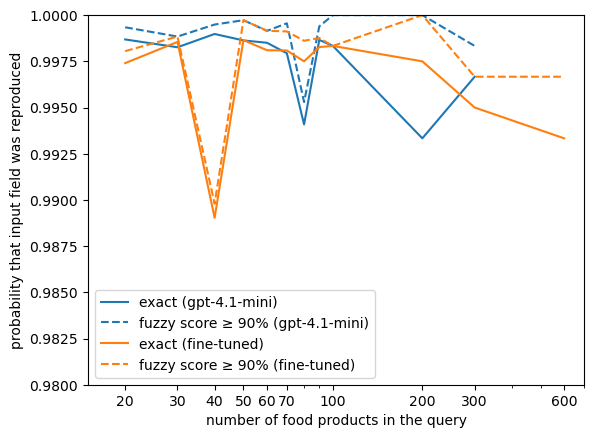

In [9]:
fig, ax = plt.subplots()

multiplicities = sorted(df_category_untuned["multiplicity"].unique())
all_multiplicities = set(multiplicities)
fraction100 = []
fraction90 = []
for multiplicity in multiplicities:
    df_this_multiplicity = df_category_untuned.query(f"multiplicity == {multiplicity}")
    fraction100.append(np.count_nonzero(df_this_multiplicity["inputfuzz"] == 100) / len(df_this_multiplicity))
    fraction90.append(np.count_nonzero(df_this_multiplicity["inputfuzz"] >= 90) / len(df_this_multiplicity))
ax.plot(multiplicities, fraction100, color="tab:blue", ls="-", label="exact (gpt-4.1-mini)")
ax.plot(multiplicities, fraction90, color="tab:blue", ls="--", label="fuzzy score ≥ 90% (gpt-4.1-mini)")

multiplicities = sorted(df_category_finetuned["multiplicity"].unique())
all_multiplicities = all_multiplicities.union(multiplicities)
fraction100 = []
fraction90 = []
for multiplicity in multiplicities:
    df_this_multiplicity = df_category_finetuned.query(f"multiplicity == {multiplicity}")
    fraction100.append(np.count_nonzero(df_this_multiplicity["inputfuzz"] == 100) / len(df_this_multiplicity))
    fraction90.append(np.count_nonzero(df_this_multiplicity["inputfuzz"] >= 90) / len(df_this_multiplicity))
ax.plot(multiplicities, fraction100, color="tab:orange", ls="-", label="exact (fine-tuned)")
ax.plot(multiplicities, fraction90, color="tab:orange", ls="--", label="fuzzy score ≥ 90% (fine-tuned)")

ax.set_xlabel("number of food products in the query")
ax.set_ylabel("probability that input field was reproduced")
ax.set_xscale("log")
ax.set_xlim(15, 700)
ax.set_xticks([x for x in all_multiplicities if x not in (80, 90)])
ax.set_xticklabels([str(x) for x in all_multiplicities if x not in (80, 90)])
ax.set_ylim(0.98, 1)
ax.legend()

None

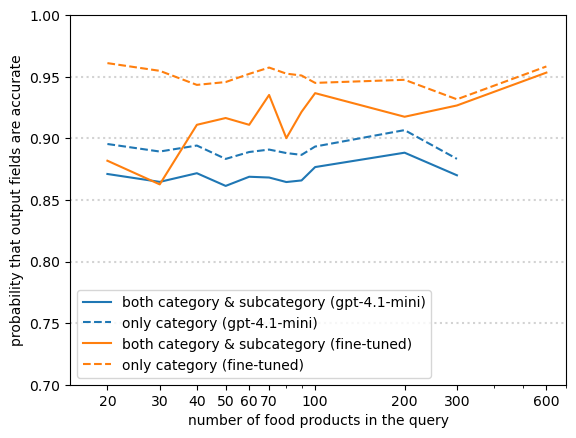

In [10]:
fig, ax = plt.subplots()

for level in np.arange(0.75, 1, 0.05):
    ax.axhline(level, color="lightgrey", ls=":")

multiplicities = sorted(df_category_untuned["multiplicity"].unique())
all_multiplicities = set(multiplicities)
fraction1 = []
fraction2 = []
for multiplicity in multiplicities:
    df_this_multiplicity = df_category_untuned.query(f"multiplicity == {multiplicity}")
    fraction1.append(np.count_nonzero(df_this_multiplicity["good_category"]) / len(df_this_multiplicity))
    fraction2.append(np.count_nonzero(df_this_multiplicity["good_category"] & df_this_multiplicity["good_subcategory"]) / len(df_this_multiplicity))
ax.plot(multiplicities, fraction2, color="tab:blue", ls="-", label="both category & subcategory (gpt-4.1-mini)")
ax.plot(multiplicities, fraction1, color="tab:blue", ls="--", label="only category (gpt-4.1-mini)")

multiplicities = sorted(df_category_finetuned["multiplicity"].unique())
all_multiplicities = all_multiplicities.union(multiplicities)
fraction1 = []
fraction2 = []
for multiplicity in multiplicities:
    df_this_multiplicity = df_category_finetuned.query(f"multiplicity == {multiplicity}")
    fraction1.append(np.count_nonzero(df_this_multiplicity["good_category"]) / len(df_this_multiplicity))
    fraction2.append(np.count_nonzero(df_this_multiplicity["good_category"] & df_this_multiplicity["good_subcategory"]) / len(df_this_multiplicity))
ax.plot(multiplicities, fraction2, color="tab:orange", ls="-", label="both category & subcategory (fine-tuned)")
ax.plot(multiplicities, fraction1, color="tab:orange", ls="--", label="only category (fine-tuned)")

ax.set_xlabel("number of food products in the query")
ax.set_ylabel("probability that output fields are accurate")
ax.set_xscale("log")
ax.set_xlim(15, 700)
ax.set_xticks([x for x in all_multiplicities if x not in (80, 90)])
ax.set_xticklabels([str(x) for x in all_multiplicities if x not in (80, 90)])
ax.set_ylim(0.7, 1)
ax.legend()

None

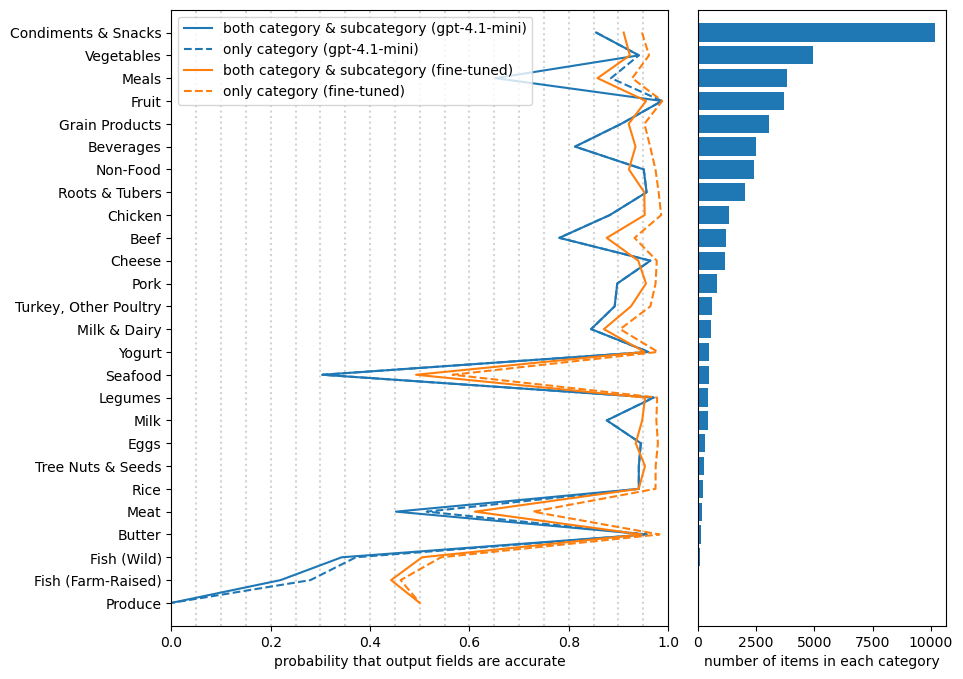

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[10, 8], gridspec_kw=dict(width_ratios=[2, 1], wspace=0.08))

category_counts = df_category_untuned["category"].value_counts().to_dict()

for level in np.arange(0.05, 1, 0.05):
    ax1.axvline(level, color="lightgrey", ls=":")

fraction1 = []
fraction2 = []
for category, count in category_counts.items():
    df_this_category = df_category_untuned.query(f"category == {category!r}")
    fraction1.append(np.count_nonzero(df_this_category["good_category"]) / len(df_this_category))
    fraction2.append(np.count_nonzero(df_this_category["good_category"] & df_this_category["good_subcategory"]) / len(df_this_category))
ax1.plot(fraction2, range(len(category_counts))[::-1], color="tab:blue", ls="-", label="both category & subcategory (gpt-4.1-mini)")
ax1.plot(fraction1, range(len(category_counts))[::-1], color="tab:blue", ls="--", label="only category (gpt-4.1-mini)")

fraction1 = []
fraction2 = []
for category, count in category_counts.items():
    df_this_category = df_category_finetuned.query(f"category == {category!r}")
    fraction1.append(np.count_nonzero(df_this_category["good_category"]) / len(df_this_category))
    fraction2.append(np.count_nonzero(df_this_category["good_category"] & df_this_category["good_subcategory"]) / len(df_this_category))
ax1.plot(fraction2, range(len(category_counts))[::-1], color="tab:orange", ls="-", label="both category & subcategory (fine-tuned)")
ax1.plot(fraction1, range(len(category_counts))[::-1], color="tab:orange", ls="--", label="only category (fine-tuned)")

ax1.set_yticks(range(len(category_counts)), list(category_counts)[::-1])
ax1.set_xlabel("probability that output fields are accurate")
ax1.set_xlim(0, 1)
ax1.set_ylim(-1, len(category_counts))
ax1.legend(loc="upper left")

ax2.barh(range(len(category_counts)), list(category_counts.values())[::-1])

ax2.set_yticks([])
ax2.set_xlabel("number of items in each category")
ax2.set_ylim(-1, len(category_counts))

None

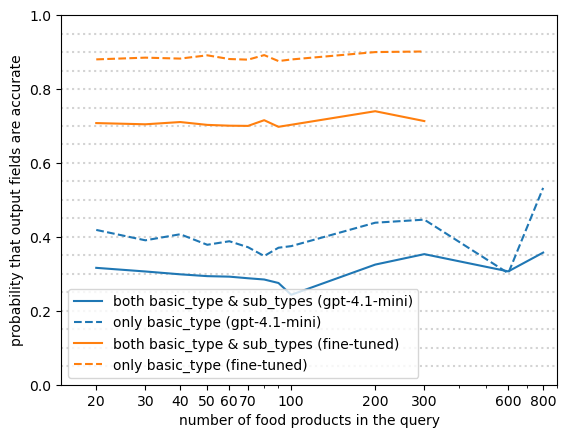

In [12]:
fig, ax = plt.subplots()

for level in np.arange(0.05, 1, 0.05):
    ax.axhline(level, color="lightgrey", ls=":")

multiplicities = sorted(df_tag_untuned["multiplicity"].unique())
all_multiplicities = set(multiplicities)
fraction1 = []
fraction2 = []
for multiplicity in multiplicities:
    df_this_multiplicity = df_tag_untuned.query(f"multiplicity == {multiplicity}")
    fraction1.append(np.count_nonzero(df_this_multiplicity["basic_type"]) / len(df_this_multiplicity))
    fraction2.append(np.count_nonzero(df_this_multiplicity["sub_types"]) / len(df_this_multiplicity))
ax.plot(multiplicities, fraction2, color="tab:blue", ls="-", label="both basic_type & sub_types (gpt-4.1-mini)")
ax.plot(multiplicities, fraction1, color="tab:blue", ls="--", label="only basic_type (gpt-4.1-mini)")

multiplicities = sorted(df_tag_finetuned["multiplicity"].unique())
all_multiplicities = all_multiplicities.union(multiplicities)
fraction1 = []
fraction2 = []
for multiplicity in multiplicities:
    df_this_multiplicity = df_tag_finetuned.query(f"multiplicity == {multiplicity}")
    fraction1.append(np.count_nonzero(df_this_multiplicity["basic_type"]) / len(df_this_multiplicity))
    fraction2.append(np.count_nonzero(df_this_multiplicity["sub_types"]) / len(df_this_multiplicity))
ax.plot(multiplicities, fraction2, color="tab:orange", ls="-", label="both basic_type & sub_types (fine-tuned)")
ax.plot(multiplicities, fraction1, color="tab:orange", ls="--", label="only basic_type (fine-tuned)")

ax.set_xlabel("number of food products in the query")
ax.set_ylabel("probability that output fields are accurate")
ax.set_xscale("log")
ax.set_xlim(15, 900)
ax.set_xticks([x for x in all_multiplicities if x not in (80, 90)])
ax.set_xticklabels([str(x) for x in all_multiplicities if x not in (80, 90)])
ax.set_ylim(0, 1)
ax.legend()

None

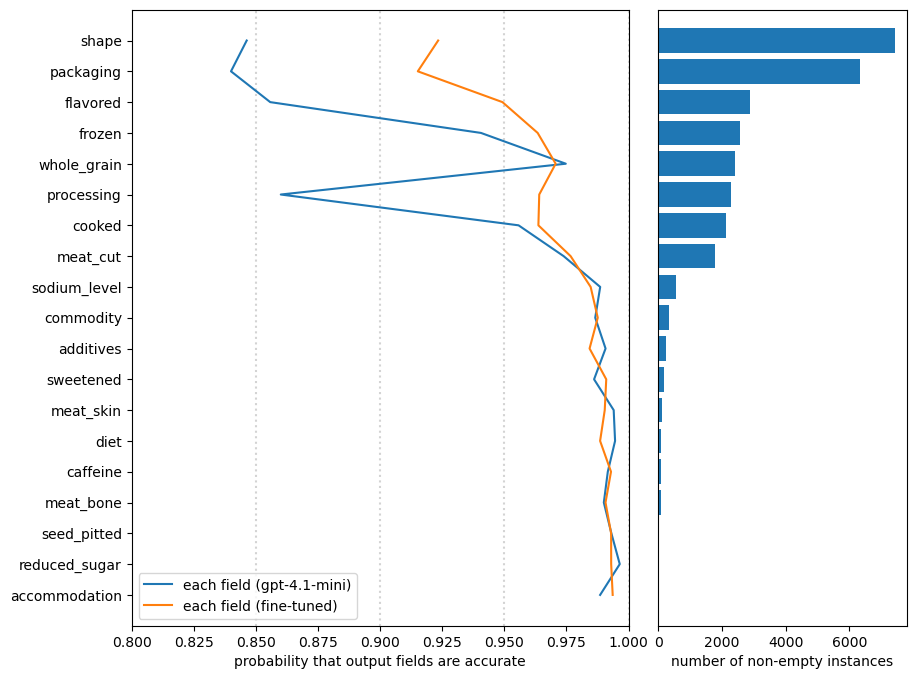

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[10, 8], gridspec_kw=dict(width_ratios=[2, 1], wspace=0.08))

field_counts = sorted(filled_untuned.items(), key=lambda x: -x[1])

for level in np.arange(0.85, 1, 0.05):
    ax1.axvline(level, color="lightgrey", ls=":")

fraction = []
for field, count in field_counts:
    fraction.append(np.count_nonzero(df_tag_untuned[field]) / len(df_tag_untuned))
ax1.plot(fraction, range(len(field_counts))[::-1], color="tab:blue", ls="-", label="each field (gpt-4.1-mini)")

fraction = []
for field, count in field_counts:
    fraction.append(np.count_nonzero(df_tag_finetuned[field]) / len(df_tag_finetuned))
ax1.plot(fraction, range(len(field_counts))[::-1], color="tab:orange", ls="-", label="each field (fine-tuned)")

ax1.set_yticks(range(len(field_counts)), [name for name, count in field_counts][::-1])
ax1.set_xlabel("probability that output fields are accurate")
ax1.set_xlim(0.8, 1)
ax1.set_ylim(-1, len(field_counts))
ax1.legend(loc="lower left")

ax2.barh(range(len(field_counts)), [count for name, count in field_counts][::-1])

ax2.set_yticks([])
ax2.set_xlabel("number of non-empty instances")
ax2.set_ylim(-1, len(field_counts))

None

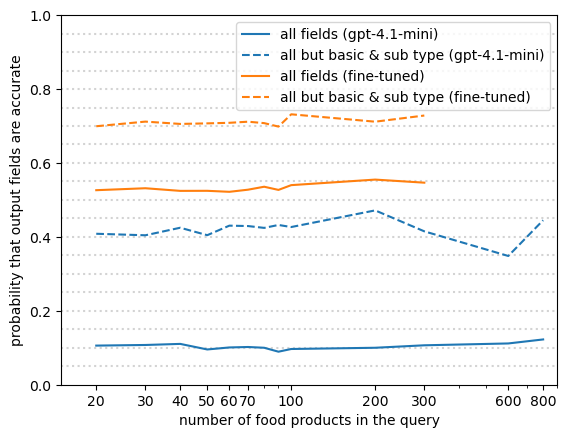

In [14]:
fig, ax = plt.subplots()

for level in np.arange(0.05, 1, 0.05):
    ax.axhline(level, color="lightgrey", ls=":")

multiplicities = sorted(df_tag_untuned["multiplicity"].unique())
all_multiplicities = set(multiplicities)
fractionall = []
fractionmost = []
for multiplicity in multiplicities:
    df_this_multiplicity = df_tag_untuned.query(f"multiplicity == {multiplicity}")
    fractionall.append(np.count_nonzero(df_this_multiplicity.iloc[:, 2:].all(axis=1)) / len(df_this_multiplicity))
    fractionmost.append(np.count_nonzero(df_this_multiplicity.iloc[:, 4:].all(axis=1)) / len(df_this_multiplicity))
ax.plot(multiplicities, fractionall, color="tab:blue", ls="-", label="all fields (gpt-4.1-mini)")
ax.plot(multiplicities, fractionmost, color="tab:blue", ls="--", label="all but basic & sub type (gpt-4.1-mini)")

multiplicities = sorted(df_tag_finetuned["multiplicity"].unique())
all_multiplicities = all_multiplicities.union(multiplicities)
fractionall = []
fractionmost = []
for multiplicity in multiplicities:
    df_this_multiplicity = df_tag_finetuned.query(f"multiplicity == {multiplicity}")
    fractionall.append(np.count_nonzero(df_this_multiplicity.iloc[:, 2:].all(axis=1)) / len(df_this_multiplicity))
    fractionmost.append(np.count_nonzero(df_this_multiplicity.iloc[:, 4:].all(axis=1)) / len(df_this_multiplicity))
ax.plot(multiplicities, fractionall, color="tab:orange", ls="-", label="all fields (fine-tuned)")
ax.plot(multiplicities, fractionmost, color="tab:orange", ls="--", label="all but basic & sub type (fine-tuned)")

ax.set_xlabel("number of food products in the query")
ax.set_ylabel("probability that output fields are accurate")
ax.set_xscale("log")
ax.set_xlim(15, 900)
ax.set_xticks([x for x in all_multiplicities if x not in (80, 90)])
ax.set_xticklabels([str(x) for x in all_multiplicities if x not in (80, 90)])
ax.set_ylim(0, 1)
ax.legend()

None

In [15]:
encoding = tiktoken.encoding_for_model("gpt-4.1-mini")

In [16]:
with open("category-instructions.md") as file:
    category_instructions = file.read()

with open("category-schema.json") as file:
    category_schema = file.read()

with open("tag-instructions.md") as file:
    tag_instructions = file.read()

with open("tag-schema.json") as file:
    tag_schema = file.read()

category_instructions = f"""
Your job is to read a set of food product names and categorize them. The input
is formatted as

```json
{{"food_products": [...]}}
```

where each object in `...` contains a food product description in its `"input"`.
You need to produce a similar JSON object in which each of the output `"food_products"`
corresponds to one of the inputs, repeating the `"input"` value exactly and adding
category attributes as described below.

{category_instructions}
""".strip()

tag_instructions = f"""
Your job is to read a set of food product names and assign tags to them. The input
is formatted as

```json
{{"food_products": [...]}}
```

where each object in `...` contains a food product description in its `"input"`.
You need to produce a similar JSON object in which each of the output `"food_products"`
corresponds to one of the inputs, repeating the `"input"` value exactly and adding
tag attributes as described below.

{tag_instructions}
""".strip()

category_instructions_tokens = len(encoding.encode(category_instructions))
category_schema_tokens = len(encoding.encode(category_schema))
tag_instructions_tokens = len(encoding.encode(tag_instructions))
tag_schema_tokens = len(encoding.encode(tag_schema))

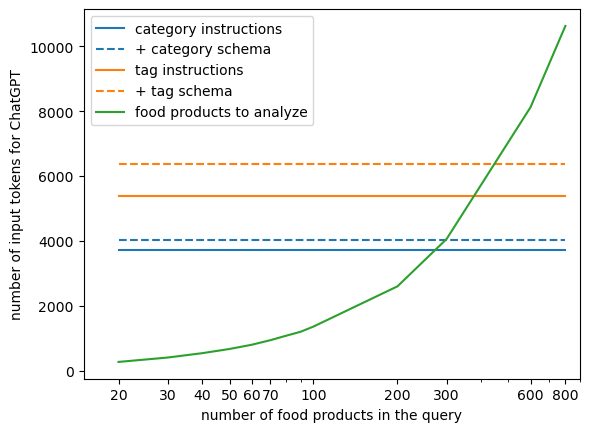

In [17]:
fig, ax = plt.subplots()

ax.plot([20, 800], [category_instructions_tokens] * 2, color="tab:blue", label="category instructions")
ax.plot([20, 800], [category_instructions_tokens + category_schema_tokens] * 2, ls="--", color="tab:blue", label="+ category schema")
ax.plot([20, 800], [tag_instructions_tokens] * 2, color="tab:orange", label="tag instructions")
ax.plot([20, 800], [tag_instructions_tokens + tag_schema_tokens] * 2, ls="--", color="tab:orange", label="+ tag schema")

multiplicities = sorted(df_tag_untuned["multiplicity"].unique())
num_tokens = []
for multiplicity in multiplicities:
    df_this_multiplicity = df_tag_untuned.query(f"multiplicity == {multiplicity}")
    num_tokens.append(sum(len(encoding.encode(x)) for x in df_this_multiplicity["input"]) * multiplicity / len(df_this_multiplicity))
ax.plot(multiplicities, num_tokens, ls="-", color="tab:green", label="food products to analyze")

ax.set_xlabel("number of food products in the query")
ax.set_ylabel("number of input tokens for ChatGPT")
ax.set_xscale("log")
ax.set_xlim(15, 900)
ax.set_xticks([x for x in multiplicities if x not in (80, 90)])
ax.set_xticklabels([str(x) for x in multiplicities if x not in (80, 90)])
ax.legend()

None

In [18]:
df_untuned = df_category_untuned.merge(df_tag_untuned, on=["input", "multiplicity"])
df_untuned_meals = df_untuned.query("actual_category == 'Meals'")
df_untuned_meats = df_untuned.query("actual_category in ['Seafood', 'Meat', 'Fish (Farm-Raised)', 'Fish (Wild)']")
df_untuned_other = df_untuned.query("actual_category not in ['Meals', 'Seafood', 'Meat', 'Fish (Farm-Raised)', 'Fish (Wild)']")

In [19]:
df_finetuned = df_category_finetuned.merge(df_tag_finetuned, on=["input", "multiplicity"])
df_finetuned_meals = df_finetuned.query("actual_category == 'Meals'")
df_finetuned_meats = df_finetuned.query("actual_category in ['Seafood', 'Meat', 'Fish (Farm-Raised)', 'Fish (Wild)']")
df_finetuned_other = df_finetuned.query("actual_category not in ['Meals', 'Seafood', 'Meat', 'Fish (Farm-Raised)', 'Fish (Wild)']")

In [20]:
print(f"""Bottom-line probabilities that the category and tag predictions are entirely correct:

untuned (model says \"Meals\"): {100 * np.count_nonzero(df_untuned_meals.iloc[:, 6:].all(axis=1)) / len(df_untuned_meals):.1f}%
untuned (model says \"Meat\", \"Seafood\", \"Fish\" (wild or farm-raised): {100 * np.count_nonzero(df_untuned_meats.iloc[:, 6:].all(axis=1)) / len(df_untuned_meats):.1f}%
untuned (model says anything else): {100 * np.count_nonzero(df_untuned_other.iloc[:, 6:].all(axis=1)) / len(df_untuned_other):.1f}%
untuned (all together): {100 * np.count_nonzero(df_untuned.iloc[:, 6:].all(axis=1)) / len(df_untuned):.1f}%

fine-tuned (model says \"Meals\"): {100 * np.count_nonzero(df_finetuned_meals.iloc[:, 6:].all(axis=1)) / len(df_finetuned_meals):.1f}%
fine-tuned (model says \"Meat\", \"Seafood\", \"Fish\" (wild or farm-raised): {100 * np.count_nonzero(df_finetuned_meats.iloc[:, 6:].all(axis=1)) / len(df_finetuned_meats):.1f}%
fine-tuned (model says anything else): {100 * np.count_nonzero(df_finetuned_other.iloc[:, 6:].all(axis=1)) / len(df_finetuned_other):.1f}%
fine-tuned (all together): {100 * np.count_nonzero(df_finetuned.iloc[:, 6:].all(axis=1)) / len(df_finetuned):.1f}%
""")

Bottom-line probabilities that the category and tag predictions are entirely correct:

untuned (model says "Meals"): 0.9%
untuned (model says "Meat", "Seafood", "Fish" (wild or farm-raised): 2.9%
untuned (model says anything else): 10.8%
untuned (all together): 9.5%

fine-tuned (model says "Meals"): 26.1%
fine-tuned (model says "Meat", "Seafood", "Fish" (wild or farm-raised): 18.8%
fine-tuned (model says anything else): 52.7%
fine-tuned (all together): 49.7%

